## Mean Imputation

In [131]:
import numpy as np
import pandas as pd

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer

data = load_breast_cancer()

X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name="target")

X.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,radius error,texture error,perimeter error,area error,smoothness error,compactness error,concavity error,concave points error,symmetry error,fractal dimension error,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,0.4956,1.1560,3.445,27.23,0.009110,0.07458,0.05661,0.01867,0.05963,0.009208,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,0.7572,0.7813,5.438,94.44,0.011490,0.02461,0.05688,0.01885,0.01756,0.005115,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [132]:
X.shape

(569, 30)

In [133]:
X.isna().sum().sum()

np.int64(0)

In [134]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [135]:
print("Training set:", X_train.shape)
print("Test set:", X_test.shape)

Training set: (455, 30)
Test set: (114, 30)


In [136]:
def introduce_missingness(X, missing_rate, random_state=None):

    # 1. Make a copy
    X_missing = X.copy()

    # 2. Calculate number of cells
    no_cells = X.shape[0] * X.shape[1]

    # 3. Calculate number of missing values
    no_missing = int(no_cells * missing_rate)

    # 4. Create random number generator
    rng = np.random.default_rng(random_state)

    # 5. Randomly select unique cells
    indices = rng.choice(no_cells, size=no_missing, replace=False)

    # 6. Convert selected positions to row/column indices
    rows, columns = np.unravel_index(indices, X.shape)

    # 7. Replace those cells with NaN
    X_missing.values[rows, columns] = np.nan


    # 8. Return modified copy
    return X_missing

In [137]:
X_train_10 = introduce_missingness(
    X_train,
    missing_rate=0.10,
    random_state=42
)

X_test_10 = introduce_missingness(
    X_test,
    missing_rate=0.10,
    random_state=43
)

In [138]:
print("Training missing values:")
print(X_train_10.isna().sum().sum())

print("Test missing values:")
print(X_test_10.isna().sum().sum())

Training missing values:
1365
Test missing values:
342


In [139]:
# Mean Experiment 
mean_imputer = SimpleImputer(strategy="mean")

mean_imputer.fit(X_train_10)

X_train_mean = mean_imputer.transform(X_train_10)
# X_train_mean = mean_imputer.fit_transform(X_train_10)
X_test_mean = mean_imputer.transform(X_test_10)

In [140]:
# See the learned means when fit() is called
mean_imputer.statistics_

array([1.41382371e+01, 1.91641422e+01, 9.20022829e+01, 6.49137913e+02,
       9.61611529e-02, 1.04511446e-01, 9.09744883e-02, 4.78097371e-02,
       1.81241951e-01, 6.29788862e-02, 3.98833010e-01, 1.22408836e+00,
       2.86660049e+00, 3.89786495e+01, 7.10683212e-03, 2.56925599e-02,
       3.22956900e-02, 1.16536858e-02, 2.07482794e-02, 3.81398266e-03,
       1.60308689e+01, 2.56929197e+01, 1.06322086e+02, 8.61354988e+02,
       1.32385072e-01, 2.56047212e-01, 2.75955137e-01, 1.11918069e-01,
       2.89190732e-01, 8.36591521e-02])

In [141]:
# Convert Numpy array into DataFrame
earned_means = pd.Series(
    mean_imputer.statistics_,
    index=X_train_10.columns
)

learned_means

mean radius                 14.138237
mean texture                19.164142
mean perimeter              92.002283
mean area                  649.137913
mean smoothness              0.096161
mean compactness             0.104511
mean concavity               0.090974
mean concave points          0.047810
mean symmetry                0.181242
mean fractal dimension       0.062979
radius error                 0.398833
texture error                1.224088
perimeter error              2.866600
area error                  38.978650
smoothness error             0.007107
compactness error            0.025693
concavity error              0.032296
concave points error         0.011654
symmetry error               0.020748
fractal dimension error      0.003814
worst radius                16.030869
worst texture               25.692920
worst perimeter            106.322086
worst area                 861.354988
worst smoothness             0.132385
worst compactness            0.256047
worst concav

In [142]:
# Mean SimpleImputer learn for the mean radius feature
learned_means["mean radius"]

np.float64(14.138237089201878)

In [143]:
# Calculate the mean of the mean radius column
X_train_10["mean radius"].mean()

np.float64(14.138237089201878)

## Median Imputation

In [144]:
# Median Imputation

from sklearn.impute import SimpleImputer

median_imputer = SimpleImputer(strategy="median")

X_train_median = median_imputer.fit_transform(X_train_10)

X_test_median = median_imputer.transform(X_test_10)

In [145]:
# Check missing values
print("Training missing values:", np.isnan(X_train_median).sum())
print("Test missing values:", np.isnan(X_test_median).sum())

Training missing values: 0
Test missing values: 0


In [146]:
median_imputer.statistics_

array([1.3310e+01, 1.8725e+01, 8.6100e+01, 5.4520e+02, 9.5240e-02,
       9.1590e-02, 6.1260e-02, 3.2390e-02, 1.7840e-01, 6.1550e-02,
       3.1380e-01, 1.0780e+00, 2.2890e+00, 2.4300e+01, 6.3690e-03,
       2.0170e-02, 2.5860e-02, 1.0650e-02, 1.8690e-02, 3.1160e-03,
       1.4750e+01, 2.5470e+01, 9.7580e+01, 6.8460e+02, 1.3195e-01,
       2.1065e-01, 2.2980e-01, 9.5320e-02, 2.8065e-01, 8.0040e-02])

In [147]:
# Inspect learned medians
learned_medians = pd.Series(
    median_imputer.statistics_,
    index=X_train_10.columns
)

learned_medians

mean radius                 13.310000
mean texture                18.725000
mean perimeter              86.100000
mean area                  545.200000
mean smoothness              0.095240
mean compactness             0.091590
mean concavity               0.061260
mean concave points          0.032390
mean symmetry                0.178400
mean fractal dimension       0.061550
radius error                 0.313800
texture error                1.078000
perimeter error              2.289000
area error                  24.300000
smoothness error             0.006369
compactness error            0.020170
concavity error              0.025860
concave points error         0.010650
symmetry error               0.018690
fractal dimension error      0.003116
worst radius                14.750000
worst texture               25.470000
worst perimeter             97.580000
worst area                 684.600000
worst smoothness             0.131950
worst compactness            0.210650
worst concav

## KNN imputation

In [148]:
from sklearn.impute import KNNImputer

X_train_10 = introduce_missingness(
    X_train,
    0.10,
    random_state=42
)

In [149]:
X_train_10.isna().sum().sum()

np.int64(1365)

In [150]:
# Create KNN imputer
knn_imputer = KNNImputer(
    n_neighbors=5
)

In [151]:
# Fit and transform the training data
X_train_knn = knn_imputer.fit_transform(
    X_train_10
)

In [152]:
# Check missing values
np.isnan(X_train_knn).sum()

np.int64(0)

In [153]:
# Convert Numpy array returned by KNNImputer back to DataFrame
X_train_knn = pd.DataFrame(
    X_train_knn,
    columns=X_train.columns,
    index=X_train.index
)

In [154]:
X_train_10.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,radius error,texture error,perimeter error,area error,smoothness error,compactness error,concavity error,concave points error,symmetry error,fractal dimension error,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
546,10.32,16.35,65.31,324.9,0.09434,0.04994,0.01012,0.005495,0.1885,0.06201,0.2104,0.967,1.356,12.97,0.007086,0.007247,0.01012,0.005495,0.01560,0.002606,11.25,21.77,71.12,384.9,0.1285,0.08842,0.04384,0.02381,0.2681,0.07399
432,20.18,19.54,133.80,1250.0,0.11330,0.14890,0.21330,0.125900,0.1724,0.06053,0.4331,1.001,3.008,52.49,0.009087,0.027150,0.05546,0.019100,0.02451,0.004005,22.03,25.07,146.00,1479.0,0.1665,NaN,0.53080,0.21730,NaN,0.08075
174,10.66,15.15,NaN,349.6,0.08792,0.04302,0.00000,0.000000,0.1928,NaN,NaN,1.925,2.155,21.98,0.008713,0.010170,0.00000,0.000000,0.03265,0.001002,11.54,19.20,73.20,408.3,0.1076,NaN,0.00000,0.00000,0.2710,0.06164
221,13.56,NaN,NaN,561.3,0.10510,0.11920,0.07860,0.044510,0.1962,NaN,NaN,NaN,2.011,21.03,0.005851,0.023140,NaN,0.008360,0.01842,0.002918,14.98,17.13,101.10,686.6,0.1376,0.26980,0.25770,0.09090,0.3065,0.08177
289,11.37,18.89,72.17,396.0,0.08713,0.05008,0.02399,0.021730,0.2013,0.05955,0.2656,1.974,NaN,17.49,NaN,0.013950,0.01376,0.009924,0.03416,0.002928,12.36,26.14,79.29,459.3,0.1118,0.09708,0.07529,0.06203,0.3267,0.06994


In [155]:
X_train_knn.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,radius error,texture error,perimeter error,area error,smoothness error,compactness error,concavity error,concave points error,symmetry error,fractal dimension error,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
546,10.32,16.350,65.310,324.9,0.09434,0.04994,0.01012,0.005495,0.1885,0.062010,0.21040,0.96700,1.3560,12.97,0.007086,0.007247,0.010120,0.005495,0.01560,0.002606,11.25,21.77,71.12,384.9,0.1285,0.088420,0.04384,0.02381,0.2681,0.07399
432,20.18,19.540,133.800,1250.0,0.11330,0.14890,0.21330,0.125900,0.1724,0.060530,0.43310,1.00100,3.0080,52.49,0.009087,0.027150,0.055460,0.019100,0.02451,0.004005,22.03,25.07,146.00,1479.0,0.1665,0.300960,0.53080,0.21730,0.2785,0.08075
174,10.66,15.150,70.094,349.6,0.08792,0.04302,0.00000,0.000000,0.1928,0.061428,0.27282,1.92500,2.1550,21.98,0.008713,0.010170,0.000000,0.000000,0.03265,0.001002,11.54,19.20,73.20,408.3,0.1076,0.113724,0.00000,0.00000,0.2710,0.06164
221,13.56,17.844,85.422,561.3,0.10510,0.11920,0.07860,0.044510,0.1962,0.061914,0.27700,1.00256,2.0110,21.03,0.005851,0.023140,0.019368,0.008360,0.01842,0.002918,14.98,17.13,101.10,686.6,0.1376,0.269800,0.25770,0.09090,0.3065,0.08177
289,11.37,18.890,72.170,396.0,0.08713,0.05008,0.02399,0.021730,0.2013,0.059550,0.26560,1.97400,1.5952,17.49,0.007161,0.013950,0.013760,0.009924,0.03416,0.002928,12.36,26.14,79.29,459.3,0.1118,0.097080,0.07529,0.06203,0.3267,0.06994


In [156]:
knn_3 = KNNImputer(n_neighbors=3)

knn_10 = KNNImputer(n_neighbors=10)

X_train_knn_3 = knn_3.fit_transform(X_train_10)

X_train_knn_10 = knn_10.fit_transform(X_train_10)

In [157]:
X_train.describe().T[["min", "max"]]

,min,max
mean radius,6.981000,28.11000
mean texture,9.710000,39.28000
mean perimeter,43.790000,188.50000
mean area,143.500000,2499.00000
mean smoothness,0.062510,0.14470
mean compactness,0.019380,0.34540
mean concavity,0.000000,0.42680
mean concave points,0.000000,0.20120
mean symmetry,0.106000,0.30400
mean fractal dimension,0.049960,0.09744


## Experimental Setup

In [158]:
from sklearn.impute import SimpleImputer, KNNImputer

imputers = {
    "Mean": SimpleImputer(strategy="mean"),
    "Median": SimpleImputer(strategy="median"),
    "KNN": KNNImputer(n_neighbors=5)
}

In [159]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(random_state=42)
}

In [160]:
# Evaluation function
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

def evaluate_model(model, X_test, y_test):
    predictions = model.predict(X_test)
    probabilities = model.predict_proba(X_test)[:, 1]

    accuracy = accuracy_score(y_test, predictions)
    f1 = f1_score(y_test, predictions)
    auc = roc_auc_score(y_test, probabilities)

    return {
        "accuracy": accuracy,
        "f1": f1,
        "auc": auc
    }

In [161]:
# Complete-data baseline

results = []

for model_name, model in models.items():

    if model_name == "Logistic Regression":

        pipeline = Pipeline([
            ("scaler", StandardScaler()),
            ("model", model)
        ])

    else:

        pipeline = Pipeline([
            ("model", model)
        ])

    pipeline.fit(X_train, y_train)

    metrics = evaluate_model(
        pipeline,
        X_test,
        y_test
    )

    results.append({
        "missingness": 0,
        "seed": 0,
        "imputer": "None",
        "model": model_name,
        "accuracy": metrics["accuracy"],
        "f1": metrics["f1"],
        "auc": metrics["auc"],
        "rows_remaining": len(X_train)
    })

In [162]:
# Pipeline
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

missing_rates = [0.10, 0.20, 0.30, 0.50]
seeds = [1, 2, 3, 4, 5]

for missing_rate in missing_rates:
    for seed in seeds:
        X_train_missing = introduce_missingness(
            X_train,
            missing_rate,
            random_state=seed
        )

        X_test_missing = introduce_missingness(
            X_test,
            missing_rate,
            random_state=seed
        )
        
        # Complete-case analysis
        X_train_complete = X_train_missing.dropna()
        y_train_complete = y_train.loc[X_train_complete.index]

        X_test_complete = X_test_missing.dropna()
        y_test_complete = y_test.loc[X_test_complete.index]
        # Count remaining rows
        train_rows_remaining = len(X_train_complete)
        test_rows_remaining = len(X_test_complete)

        if (
            train_rows_remaining >= 10
            and y_train_complete.nunique() >= 2
            and test_rows_remaining >= 1
            and y_test_complete.nunique() >= 2
        ):
            for model_name, model in models.items():

                if model_name == "Logistic Regression":

                    pipeline = Pipeline([
                        ("scaler", StandardScaler()),
                        ("model", model)
                    ])

                else:

                    pipeline = Pipeline([
                        ("model", model)
                    ])

                pipeline.fit(
                    X_train_complete,
                    y_train_complete
                )

                metrics = evaluate_model(
                    pipeline,
                    X_test_complete,
                    y_test_complete
                )

                results.append({
                    "missingness": missing_rate,
                    "seed": seed,
                    "imputer": "Complete-case",
                    "model": model_name,
                    "accuracy": metrics["accuracy"],
                    "f1": metrics["f1"],
                    "auc": metrics["auc"],
                    "rows_remaining": train_rows_remaining
                })

        # Imputation methods
        for imputer_name, imputer in imputers.items():
            for model_name, model in models.items():
                if model_name == "Logistic Regression":

                    pipeline = Pipeline([
                        ("imputer", imputer),
                        ("scaler", StandardScaler()),
                        ("model", model)
                    ])

                else:

                    pipeline = Pipeline([
                        ("imputer", imputer),
                        ("model", model)
                    ])

                pipeline.fit(
                    X_train_missing,
                    y_train
                )

                metrics = evaluate_model(
                    pipeline,
                    X_test_missing,
                    y_test
                )

                results.append({
                    "missingness": missing_rate,
                    "seed": seed,
                    "imputer": imputer_name,
                    "model": model_name,
                    "accuracy": metrics["accuracy"],
                    "f1": metrics["f1"],
                    "auc": metrics["auc"],
                    "rows_remaining": len(X_train_missing)
                })

results_df = pd.DataFrame(results)

results_df

,missingness,seed,imputer,model,accuracy,f1,auc,rows_remaining
0,0.0,0,None,Logistic Regression,0.982456,0.986111,0.995370,455
1,0.0,0,None,Random Forest,0.956140,0.965517,0.993717,455
2,0.1,1,Mean,Logistic Regression,0.956140,0.965035,0.993056,455
3,0.1,1,Mean,Random Forest,0.947368,0.958333,0.990079,455
4,0.1,1,Median,Logistic Regression,0.947368,0.957746,0.993056,455
...,...,...,...,...,...,...,...,...
123,0.5,5,Mean,Random Forest,0.929825,0.944444,0.985119,455
124,0.5,5,Median,Logistic Regression,0.929825,0.944444,0.987765,455
125,0.5,5,Median,Random Forest,0.929825,0.944444,0.982474,455
126,0.5,5,KNN,Logistic Regression,0.894737,0.916667,0.969907,455


In [163]:
results_df.shape

(128, 8)

In [164]:
results_df.head()

,missingness,seed,imputer,model,accuracy,f1,auc,rows_remaining
0,0.0,0,None,Logistic Regression,0.982456,0.986111,0.995370,455
1,0.0,0,None,Random Forest,0.956140,0.965517,0.993717,455
2,0.1,1,Mean,Logistic Regression,0.956140,0.965035,0.993056,455
3,0.1,1,Mean,Random Forest,0.947368,0.958333,0.990079,455
4,0.1,1,Median,Logistic Regression,0.947368,0.957746,0.993056,455


In [185]:
results_df.to_csv(
    "../results/imputation_results.csv",
    index=False
)

## Results

In [173]:
summary = (
    results_df
    .groupby(
        ["missingness", "imputer", "model"]
    )
    .agg(
        n_runs=("accuracy", "count"),

        mean_accuracy=("accuracy", "mean"),
        std_accuracy=("accuracy", "std"),

        mean_f1=("f1", "mean"),
        std_f1=("f1", "std"),

        mean_auc=("auc", "mean"),
        std_auc=("auc", "std"),

        mean_rows_remaining=("rows_remaining", "mean"),
        std_rows_remaining=("rows_remaining", "std")
    )
    .reset_index()
)

summary

,missingness,imputer,model,n_runs,mean_accuracy,std_accuracy,mean_f1,std_f1,mean_auc,std_auc,mean_rows_remaining,std_rows_remaining
0,0.0,None,Logistic Regression,1,0.982456,NaN,0.986111,NaN,0.995370,NaN,455.000000,NaN
1,0.0,None,Random Forest,1,0.956140,NaN,0.965517,NaN,0.993717,NaN,455.000000,NaN
2,0.1,Complete-case,Logistic Regression,3,0.952381,0.082479,0.969697,0.052486,1.000000,0.000000,19.666667,5.131601
3,0.1,Complete-case,Random Forest,3,0.952381,0.082479,0.962963,0.064150,0.966667,0.057735,19.666667,5.131601
4,0.1,KNN,Logistic Regression,5,0.968421,0.004805,0.974785,0.003870,0.994643,0.001468,455.000000,0.000000
5,0.1,KNN,Random Forest,5,0.942105,0.010002,0.953922,0.008302,0.992460,0.000568,455.000000,0.000000
6,0.1,Mean,Logistic Regression,5,0.961404,0.013303,0.969131,0.010786,0.993915,0.001008,455.000000,0.000000
7,0.1,Mean,Random Forest,5,0.938596,0.012405,0.950966,0.010429,0.991501,0.000910,455.000000,0.000000
8,0.1,Median,Logistic Regression,5,0.956140,0.006203,0.964837,0.004984,0.993452,0.001082,455.000000,0.000000
9,0.1,Median,Random Forest,5,0.935088,0.014678,0.947990,0.012441,0.991270,0.001854,455.000000,0.000000


In [166]:
summary.shape

(28, 11)

In [186]:
summary.to_csv(
    "../results/imputation_summary.csv",
    index=False
)

In [177]:
# Calculate AUC loss
baseline = (
    summary[summary["missingness"] == 0]
    .set_index("model")["mean_auc"]
)

summary["auc_loss"] = summary.apply(
    lambda row: baseline[row["model"]] - row["mean_auc"],
    axis=1
)

In [180]:
# Summary table focusing on AUC
summary[
    [
        "missingness",
        "imputer",
        "model",
        "mean_auc",
        "std_auc",
        "auc_loss"
    ]
]

,missingness,imputer,model,mean_auc,std_auc,auc_loss
0,0.0,None,Logistic Regression,0.995370,NaN,0.000000
1,0.0,None,Random Forest,0.993717,NaN,0.000000
2,0.1,Complete-case,Logistic Regression,1.000000,0.000000,-0.004630
3,0.1,Complete-case,Random Forest,0.966667,0.057735,0.027050
4,0.1,KNN,Logistic Regression,0.994643,0.001468,0.000728
5,0.1,KNN,Random Forest,0.992460,0.000568,0.001257
6,0.1,Mean,Logistic Regression,0.993915,0.001008,0.001455
7,0.1,Mean,Random Forest,0.991501,0.000910,0.002216
8,0.1,Median,Logistic Regression,0.993452,0.001082,0.001918
9,0.1,Median,Random Forest,0.991270,0.001854,0.002447


## Visualisations

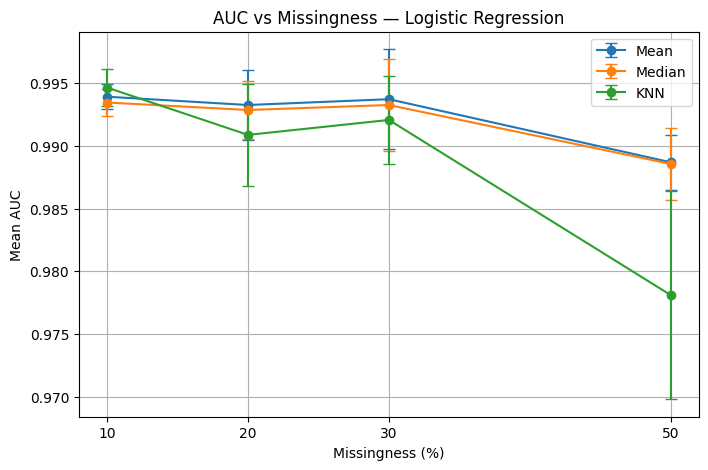

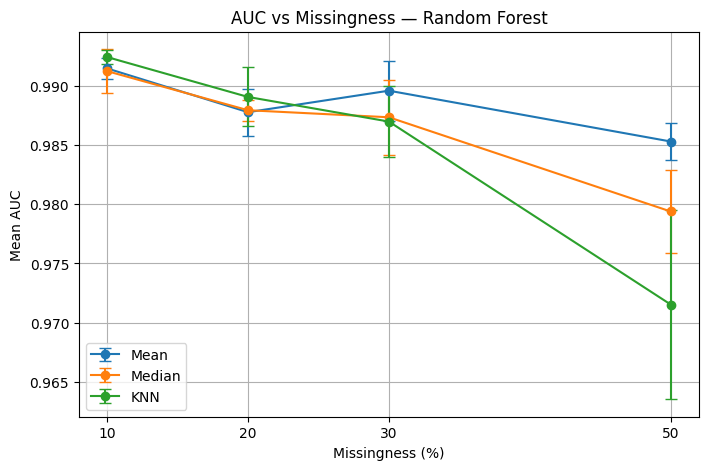

In [189]:
import matplotlib.pyplot as plt

imputation_summary = summary[
    summary["imputer"].isin(["Mean", "Median", "KNN"])
]

for model in ["Logistic Regression", "Random Forest"]:
    
    model_data = imputation_summary[
        imputation_summary["model"] == model
    ]

    plt.figure(figsize=(8, 5))

    for imputer in ["Mean", "Median", "KNN"]:
        
        imputer_data = model_data[
            model_data["imputer"] == imputer
        ]

        plt.errorbar(
            imputer_data["missingness"] * 100,
            imputer_data["mean_auc"],
            yerr=imputer_data["std_auc"],
            marker="o",
            capsize=4,
            label=imputer
        )

    plt.xlabel("Missingness (%)")
    plt.ylabel("Mean AUC")
    plt.title(f"AUC vs Missingness — {model}")
    plt.xticks([10, 20, 30, 50])
    plt.legend()
    plt.grid(True)

    if model == "Logistic Regression":
        filename = "../figures/logistic_regression_imputation.png"
    else:
        filename = "../figures/random_forest_imputation.png"

    plt.savefig(
        filename,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

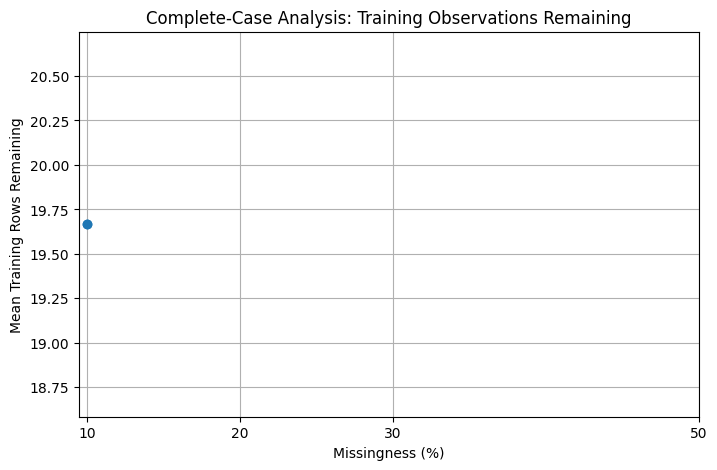

In [169]:
complete_case = summary[
    summary["imputer"] == "Complete-case"
]

plt.figure(figsize=(8, 5))

plt.plot(
    complete_case["missingness"] * 100,
    complete_case["mean_rows_remaining"],
    marker="o"
)

plt.xlabel("Missingness (%)")
plt.ylabel("Mean Training Rows Remaining")
plt.title("Complete-Case Analysis: Training Observations Remaining")
plt.xticks([10, 20, 30, 50])
plt.grid(True)
plt.show()

In [181]:
plot_data = summary[
    (summary["missingness"] > 0) &
    (summary["imputer"].isin(["Mean", "Median", "KNN"]))
]

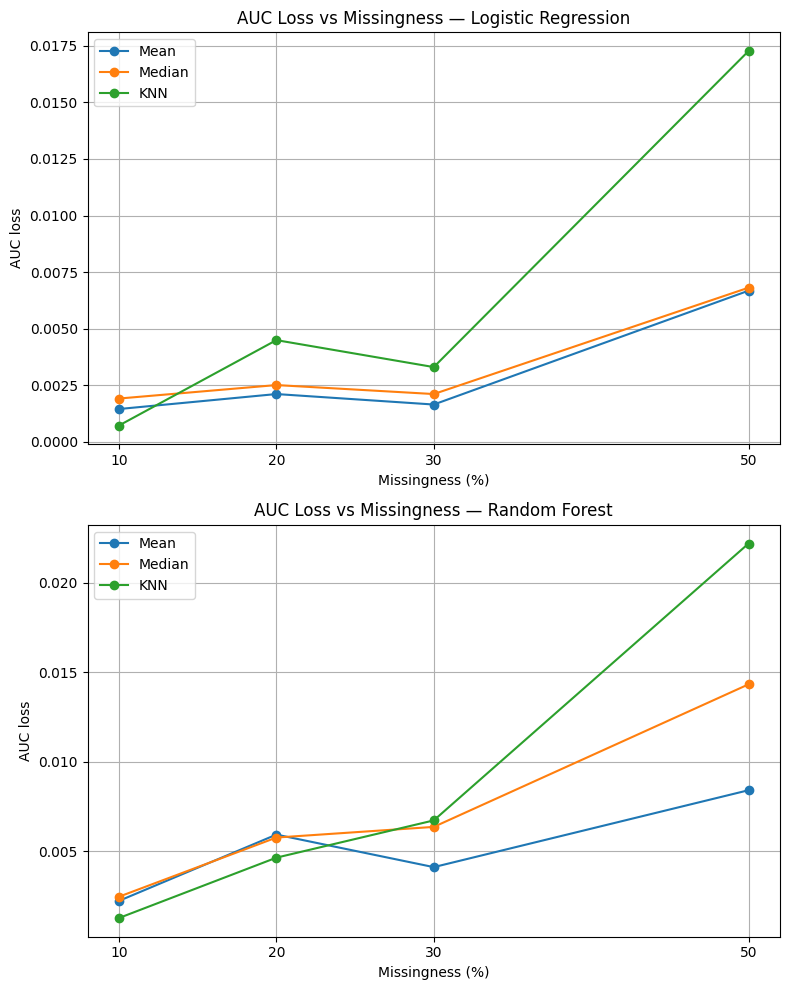

In [191]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 1, figsize=(8, 10))

for ax, model in zip(
    axes,
    ["Logistic Regression", "Random Forest"]
):

    model_data = plot_data[
        plot_data["model"] == model
    ]

    for imputer in ["Mean", "Median", "KNN"]:

        data = model_data[
            model_data["imputer"] == imputer
        ]

        ax.plot(
            data["missingness"] * 100,
            data["auc_loss"],
            marker="o",
            label=imputer
        )

    ax.set_xlabel("Missingness (%)")
    ax.set_ylabel("AUC loss")
    ax.set_title(f"AUC Loss vs Missingness — {model}")
    ax.set_xticks([10, 20, 30, 50])
    ax.legend()
    ax.grid(True)

plt.tight_layout()

plt.savefig(
    "../figures/performance_loss.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Discussion
### Logistic Regression
At 10% missingness, KNN (AUC = 0.9946), mean (0.9939), and median (0.9935) produced very similar results. At 50% missingness, mean (0.9887) and median (0.9886) remained similar, while KNN showed a larger reduction in AUC (0.9781).

Overall, the three imputation methods produced similar AUC values at lower missingness levels. At 50% missingness, KNN showed greater performance degradation, while mean and median remained relatively similar.

### Random Forest
At 50%:
Mean    0.9853
Median  0.9794
KNN     0.9715

At 50% missingness, mean imputation achieved the highest AUC (0.9853), followed by median (0.9794) and KNN (0.9715). Mean and median produced relatively similar results, while KNN showed greater degradation at high missingness.

### Effect of increasing missingness on KNN performance
KNN + Logistic Regression:
10% → 0.9946
20% → 0.9909
30% → 0.9921
50% → 0.9781

KNN + Random Forest
10% → 0.9925
20% → 0.9891
30% → 0.9870
50% → 0.9715

Increasing the missingness rate generally resulted in lower AUC, with the largest decrease occurring at 50% missingness. This suggests that the impact of missing data becomes more pronounced at higher levels of missingness.

### Standard deviations
The standard deviations were generally small for the imputation methods, indicating relatively consistent AUC across the five random seeds. However, complete-case Logistic Regression at 10% missingness had very few remaining observations, making its apparent AUC difficult to compare directly with the imputation methods.

### Overall observations
Increasing missingness generally resulted in lower model performance, with the largest degradation occurring at 50% missingness.

Mean and median imputation produced relatively similar AUC values across the experiments, while KNN did not consistently outperform the simpler methods.

Logistic Regression generally achieved higher AUC than Random Forest under the experimental conditions tested.

Complete-case analysis resulted in a substantial loss of training observations, becoming infeasible at higher missingness levels. This highlights the potential inefficiency of complete-case analysis when multiple features are subject to missingness.

### Methodological limitation
KNN preprocessing: The current KNN implementation performs feature scaling after imputation. Because KNN relies on distance calculations to identify neighbouring observations, differences in feature scale may influence neighbour selection. The preprocessing strategy will therefore be investigated and validated before the KNN results are treated as definitive.